## Correlating EOP to defense genes, AMR profiles and AMR genes

### Defense systems with EOP

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
from statsmodels.stats.multitest import multipletests

In [ ]:
#read files
defense_systems = pd.read_excel("TableS3-defenseSystems.xlsx")
eop_values = pd.read_csv("EOP_values.csv")

eop_long = eop_values.melt(id_vars=["EOP"], var_name="bacteria", value_name="EOP_value")
eop_long['EOP_value'] = pd.to_numeric(eop_long['EOP_value'], errors='coerce').fillna(0)

# Standardize bacteria names in eop_long to match defense_systems
eop_long['bacteria'] = eop_long['bacteria'].str.replace('A ', 'A. ')

defense_presence = (
    defense_systems.groupby(["bacteria", "subtype"]).size().reset_index(name="present"))
defense_presence["present"] = 1

defense_matrix = (
    defense_presence.pivot(index="bacteria", columns="subtype", values="present")
    .fillna(0)
    .reset_index()
)


# Merge EOP values with defense system presence/absence matrix
merged_eop_defense = pd.merge(eop_long, defense_matrix, on='bacteria', how='left')

# Fill NaNs in defense subtype columns after merging
defense_subtypes = [s for s in defense_systems["subtype"].unique() if pd.notna(s)]
merged_eop_defense[defense_subtypes] = merged_eop_defense[defense_subtypes].fillna(0)
merged_eop_defense

FileNotFoundError: [Errno 2] No such file or directory: 'TableS3-defenseSystems.xlsx'

In [ ]:
# Calculate correlation between EOP_value and each defense subtype
correlation_results = []
for subtype in defense_subtypes:
    if merged_eop_defense['EOP_value'].nunique() > 1 and merged_eop_defense[subtype].nunique() > 1:
        rho, p_value = spearmanr(merged_eop_defense['EOP_value'], merged_eop_defense[subtype])
        correlation_results.append({
            'defense_subtype': subtype,
            'spearman_rho': rho,
            'p_value': p_value
        })

correlation_df = pd.DataFrame(correlation_results)
correlation_df

,defense_subtype,spearman_rho,p_value
0,Hna,-0.248848,0.010473
1,AbiU,0.132201,0.178836
2,RM_Type_II,0.036142,0.714342
3,RM_Type_I,0.132201,0.178836
4,PD-T7-1,0.132201,0.178836
5,CBASS_II,0.246970,0.011089
6,Kiwa,0.027494,0.780697
7,Shedu,0.164965,0.092628
8,CBASS_III,-0.258445,0.007769


In [ ]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not correlation_df.empty:
    reject, p_adj, _, _ = multipletests(correlation_df['p_value'], method='fdr_bh')
    correlation_df['p_adj'] = p_adj
    correlation_df['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    correlation_df = pd.DataFrame(columns=['defense_subtype', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

defense_corr_df = correlation_df
defense_corr_df


,defense_subtype,spearman_rho,p_value,p_adj,significant
0,Hna,-0.248848,0.010473,0.033268,True
1,AbiU,0.132201,0.178836,0.229932,False
2,RM_Type_II,0.036142,0.714342,0.780697,False
3,RM_Type_I,0.132201,0.178836,0.229932,False
4,PD-T7-1,0.132201,0.178836,0.229932,False
5,CBASS_II,0.246970,0.011089,0.033268,True
6,Kiwa,0.027494,0.780697,0.780697,False
7,Shedu,0.164965,0.092628,0.208414,False
8,CBASS_III,-0.258445,0.007769,0.033268,True


### Antibiotic phenotypes and antibiotic reistance genes

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests  # <--- NEW

amr = pd.read_csv("amrfinderplus_all.tsv", sep="\t", dtype=str).fillna("")

# ----------------------------
# 3️⃣ Count AMR genes by Class for each bacterium
# ----------------------------
# Identify relevant columns
if "Class" in amr.columns:
    class_col = "Class"
elif "Drug Class" in amr.columns:
    class_col = "Drug Class"
else:
    raise ValueError("Could not find a 'Class' column in your AMRFinderPlus file.")

# Detect bacterium column
if "sample" in amr.columns:
    bact_col = "sample"
elif "Isolate" in amr.columns:
    bact_col = "Isolate"
else:
    raise ValueError("Could not find a bacterium identifier column (e.g., 'Sequence name').")

# Create per-bacterium counts of each AMR class
amr_counts = (
    amr.groupby([bact_col, class_col])
       .size()
       .reset_index(name="count")
       .pivot(index=bact_col, columns=class_col, values="count")
       .fillna(0)
       .reset_index()
       .rename(columns={bact_col: "bacteria"})
)

# ----------------------------
# 4️⃣ Merge with EOP data
# ----------------------------
merged = eop_long.merge(amr_counts, on="bacteria", how="left").fillna(0)
merged["log10_EOP"] = np.log10(merged["EOP_value"] + 1e-9)

# ----------------------------
# 5️⃣ Compute Spearman correlations
# ----------------------------
correlation_results = []
for amr_class in amr_counts.columns[1:]:
    if merged[amr_class].nunique() > 1 and merged["EOP_value"].nunique() > 1:
        rho, p_value = spearmanr(
            merged["EOP_value"],
            merged[amr_class],
            nan_policy="omit"
        )
        correlation_results.append({
            "AMR_class": amr_class,
            "spearman_rho": rho,
            "p_value": p_value
        })

corr_df = pd.DataFrame(correlation_results)

# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

amr_class_corr_df = corr_df

print("Spearman correlations: EOP vs AMR class counts")
display(corr_df)


Spearman correlations: EOP vs AMR class counts


,AMR_class,spearman_rho,p_value,p_adj,significant
4,TETRACYCLINE,0.373920,0.000085,0.000426,True
1,BETA-LACTAM,-0.277187,0.004201,0.010503,True
0,AMINOGLYCOSIDE,-0.236609,0.015094,0.025157,True
2,FOSFOMYCIN,-0.194413,0.046890,0.058612,False
3,PHENICOL,-0.090355,0.359323,0.359323,False


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests  # <--- NEW

amr = pd.read_csv("amrfinderplus_all.tsv", sep="\t", dtype=str).fillna("")

# ----------------------------
# 3️⃣ Count AMR genes by Class for each bacterium
# ----------------------------
# Identify relevant columns
if "Class" in amr.columns:
    class_col = "Class"
elif "Drug Class" in amr.columns:
    class_col = "Drug Class"
else:
    raise ValueError("Could not find a 'Class' column in your AMRFinderPlus file.")

# Detect bacterium column
if "sample" in amr.columns:
    bact_col = "sample"
elif "Isolate" in amr.columns:
    bact_col = "Isolate"
else:
    raise ValueError("Could not find a bacterium identifier column (e.g., 'Sequence name').")

# Create per-bacterium counts of each AMR class
amr_counts = (
    amr.groupby([bact_col, class_col])
       .size()
       .reset_index(name="count")
       .pivot(index=bact_col, columns=class_col, values="count")
       .fillna(0)
       .reset_index()
       .rename(columns={bact_col: "bacteria"})
)

# ----------------------------
# 4️⃣ Merge with EOP data
# ----------------------------
merged = eop_long.merge(amr_counts, on="bacteria", how="left").fillna(0)
merged["log10_EOP"] = np.log10(merged["EOP_value"] + 1e-9)

# ----------------------------
# 5️⃣ Compute Spearman correlations
# ----------------------------
correlation_results = []
for amr_class in amr_counts.columns[1:]:
    if merged[amr_class].nunique() > 1 and merged["EOP_value"].nunique() > 1:
        rho, p_value = spearmanr(
            merged["EOP_value"],
            merged[amr_class],
            nan_policy="omit"
        )
        correlation_results.append({
            "AMR_class": amr_class,
            "spearman_rho": rho,
            "p_value": p_value
        })

corr_df = pd.DataFrame(correlation_results)

# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

amr_class_corr_df = corr_df

print("Spearman correlations: EOP vs AMR class counts")
display(corr_df)


Spearman correlations: EOP vs AMR class counts


,AMR_class,spearman_rho,p_value,p_adj,significant
4,TETRACYCLINE,0.373920,0.000085,0.000426,True
1,BETA-LACTAM,-0.277187,0.004201,0.010503,True
0,AMINOGLYCOSIDE,-0.236609,0.015094,0.025157,True
2,FOSFOMYCIN,-0.194413,0.046890,0.058612,False
3,PHENICOL,-0.090355,0.359323,0.359323,False


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# ---------- helper to normalise bacteria names (tweak as needed) ----------
def normalize_bacteria(name):
    if isinstance(name, str):
        # example: "A. xylosoxidans jini" -> "A xylosoxidans jini"
        return name.replace("A. ", "A ").strip()
    return name

# Load
eop = pd.read_csv("EOP_values.csv")
amr = pd.read_csv("amrresults.csv")

# --- 1. Reshape EOP to long format ---
eop_long = eop.melt(id_vars=["EOP"], var_name="bacteria", value_name="EOP_value")
eop_long["EOP_value"] = pd.to_numeric(eop_long["EOP_value"], errors="coerce").fillna(0)
eop_long["bacteria"] = eop_long["bacteria"].apply(normalize_bacteria)

# --- 2. Reshape AMR (wide → long) ---
amr_long = amr.melt(id_vars=["Antibiotic"], var_name="bacteria", value_name="resistance")
amr_long.rename(columns={"Antibiotic": "antibiotic"}, inplace=True)
amr_long["bacteria"] = amr_long["bacteria"].apply(normalize_bacteria)

# --- 3. Merge ---
merged = eop_long.merge(amr_long, on="bacteria", how="left")

# --- 4. Clean & convert R/S/I to numeric ---
mapping = {"R": 1, "S": 0, "I": 0.5}

merged["resistance_clean"] = (
    merged["resistance"]
    .astype(str)
    .str.strip()
    .str.upper()
)

merged["resistance_score"] = merged["resistance_clean"].map(mapping)

# optional: quick sanity check
print("Resistance values after cleaning:")
print(merged["resistance_clean"].value_counts().head())

# --- 5. Compute correlations ---
results = []
for abx in merged["antibiotic"].dropna().unique():
    sub = merged[merged["antibiotic"] == abx].copy()
    sub = sub.dropna(subset=["resistance_score"])  # drop NaNs from unknown codes

    if sub["resistance_score"].nunique() > 1 and sub["EOP_value"].nunique() > 1:
        rho, p = spearmanr(sub["EOP_value"], sub["resistance_score"], nan_policy="omit")
        results.append({"antibiotic": abx, "rho": rho, "p_value": p})

corr_df = pd.DataFrame(results)

# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at FDR alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

antibiotic_corr_df = corr_df

print("Spearman correlation: EOP vs antibiotic resistance (per antibiotic)")
display(antibiotic_corr_df)


Resistance values after cleaning:
resistance_clean
R    930
S    270
I     60
Name: count, dtype: int64
Spearman correlation: EOP vs antibiotic resistance (per antibiotic)


,antibiotic,rho,p_value,p_adj,significant
2,Ceftazidime,0.201590,0.039191,0.313525,False
0,Piperacillin/tazobactam,-0.132521,0.177778,0.357673,False
6,Tobramycin,-0.132201,0.178836,0.357673,False
7,Trimethoprim/sulfamethoxazole,0.132521,0.177778,0.357673,False
4,Amikacin,0.085542,0.385591,0.616946,False
1,Ticarcillin/ clavulanate,0.027494,0.780697,0.892225,False
3,Meropenem,0.027494,0.780697,0.892225,False
5,Gentamicin,-0.011879,0.904270,0.904270,False


### Visualising

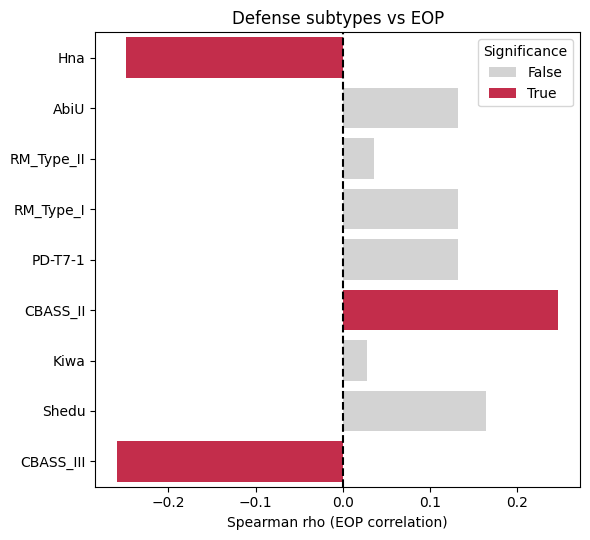

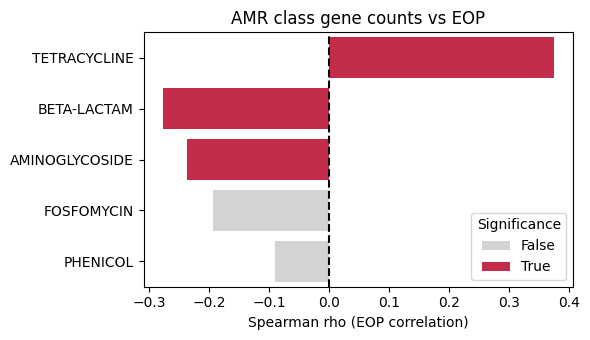

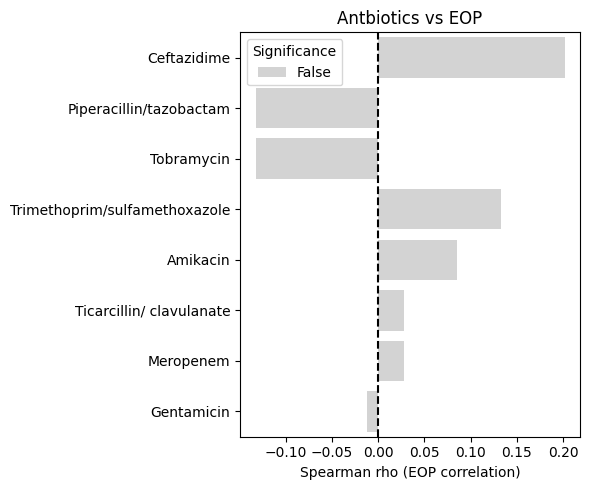

In [ ]:
# Combine simplified tables
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_correlations(df, feature_col, rho_col, p_col, title):
    df = df.copy()
    df["Significance"] = df[p_col] < 0.05
    plt.figure(figsize=(6, len(df)*0.5 + 1))
    sns.barplot(data=df, x=rho_col, y=feature_col, hue="Significance",
                palette={True: "crimson", False: "lightgrey"}, dodge=False)
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


plot_correlations(defense_corr_df, "defense_subtype", "spearman_rho", "p_adj",
                  "Defense subtypes vs EOP")

plot_correlations(amr_class_corr_df, "AMR_class", "spearman_rho", "p_adj",
                  "AMR class gene counts vs EOP")

plot_correlations(antibiotic_corr_df, "antibiotic", "rho", "p_adj",
                  "Antbiotics vs EOP")


### Correlating EOP to Receptor binding proteins and other phage tail proteins

RBP were detected using PhageRBPDetect, https://github.com/dimiboeckaerts/PhageRBPdetection




In [ ]:
# Example usage:  Replace with your desired gene IDs, from predicred PhageRBPDetect
qgeneID_subset = ["JDOEVDKM_CDS_0024", "JDOEVDKM_CDS_0028", "JDOEVDKM_CDS_0029", "AXUUMYTS_CDS_0021", "AXUUMYTS_CDS_0018", "IFXVGPNG_CDS_0028", "IFXVGPNG_CDS_0032", "IFXVGPNG_CDS_0027", "IHDRJJQR_CDS_0029", "IHDRJJQR_CDS_0034", "MPKKVJWZ_CDS_0014", "JJIYCMYV_CDS_0023", "OKILJAZK_CDS_0015", "OKILJAZK_CDS_0012", "BUBCVPIM_CDS_0027", "QLZSKYRQ_CDS_0032", "QLZSKYRQ_CDS_0029", "MOJOLAXZ_CDS_0031", "MOJOLAXZ_CDS_0024", "VCKTMGAM_CDS_0031", "VCKTMGAM_CDS_0029", "LDQZVDBU_CDS_0031", "YRFTTTDG_CDS_0017", "YRFTTTDG_CDS_0020", "VNLSRWGA_CDS_0023", "VNLSRWGA_CDS_0027", "JZFESBBW_CDS_0024"]
rgeneID_subset = ["JDOEVDKM_CDS_0024", "JDOEVDKM_CDS_0028", "JDOEVDKM_CDS_0029", "AXUUMYTS_CDS_0021", "AXUUMYTS_CDS_0018", "IFXVGPNG_CDS_0028", "IFXVGPNG_CDS_0032", "IFXVGPNG_CDS_0027", "IHDRJJQR_CDS_0029", "IHDRJJQR_CDS_0034", "MPKKVJWZ_CDS_0014", "JJIYCMYV_CDS_0023", "OKILJAZK_CDS_0015", "OKILJAZK_CDS_0012", "BUBCVPIM_CDS_0027", "QLZSKYRQ_CDS_0032", "QLZSKYRQ_CDS_0029", "MOJOLAXZ_CDS_0031", "MOJOLAXZ_CDS_0024", "VCKTMGAM_CDS_0031", "VCKTMGAM_CDS_0029", "LDQZVDBU_CDS_0031", "YRFTTTDG_CDS_0017", "YRFTTTDG_CDS_0020", "VNLSRWGA_CDS_0023", "VNLSRWGA_CDS_0027", "JZFESBBW_CDS_0024"]
# Regex pattern for tail-related genes
tail_pattern = r"(tail|fiber|spike|sheath|baseplate|rbp|receptor)"

In [ ]:
gene_matrix =pd.read_csv("Phage_gene_matrix.csv")
gene_matrix

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
0,ewik,Ewik_contig_1,0,1134,coliflower,Coliflower_contig_1,565,1129,100.0,1.140000e-108,terminase large subunit,AXUUMYTS_CDS_0001,terminase large subunit,JDOEVDKM_CDS_0002,ewik - AXUUMYTS_CDS_0001,ewik - AXUUMYTS_CDS_0001 - terminase large sub...,coliflower - JDOEVDKM_CDS_0002,coliflower - JDOEVDKM_CDS_0002 - terminase lar...
1,ewik,Ewik_contig_1,1136,2675,coliflower,Coliflower_contig_1,1483,2524,99.1,1.130000e-231,portal protein,AXUUMYTS_CDS_0002,portal protein,JDOEVDKM_CDS_0004,ewik - AXUUMYTS_CDS_0002,ewik - AXUUMYTS_CDS_0002 - portal protein,coliflower - JDOEVDKM_CDS_0004,coliflower - JDOEVDKM_CDS_0004 - portal protein
2,ewik,Ewik_contig_1,6569,7490,coliflower,Coliflower_contig_1,6915,8250,98.2,8.050000e-186,minor tail protein,AXUUMYTS_CDS_0005,minor tail protein,JDOEVDKM_CDS_0016,ewik - AXUUMYTS_CDS_0005,ewik - AXUUMYTS_CDS_0005 - minor tail protein,coliflower - JDOEVDKM_CDS_0016,coliflower - JDOEVDKM_CDS_0016 - minor tail pr...
3,ewik,Ewik_contig_1,8062,8494,coliflower,Coliflower_contig_1,8281,8647,97.1,5.070000e-68,Tail assembly chaperone,AXUUMYTS_CDS_0007,Tail assembly chaperone,JDOEVDKM_CDS_0017,ewik - AXUUMYTS_CDS_0007,ewik - AXUUMYTS_CDS_0007 - Tail assembly chape...,coliflower - JDOEVDKM_CDS_0017,coliflower - JDOEVDKM_CDS_0017 - Tail assembly...
4,ewik,Ewik_contig_1,9743,9293,coliflower,Coliflower_contig_1,9050,9500,99.3,1.200000e-94,tail length tape measure protein,AXUUMYTS_CDS_0008,tail completion or Neck1 protein,JDOEVDKM_CDS_0020,ewik - AXUUMYTS_CDS_0008,ewik - AXUUMYTS_CDS_0008 - tail length tape me...,coliflower - JDOEVDKM_CDS_0020,coliflower - JDOEVDKM_CDS_0020 - tail completi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8629,tuull,Tuull_contig_1,30540,30756,nyashin,Nyashin_contig_1,31128,31356,80.0,2.190000e-42,transcriptional repressor,YRFTTTDG_CDS_0033,transcriptional repressor,BUBCVPIM_CDS_0047,tuull - YRFTTTDG_CDS_0033,tuull - YRFTTTDG_CDS_0033 - transcriptional re...,nyashin - BUBCVPIM_CDS_0047,nyashin - BUBCVPIM_CDS_0047 - transcriptional ...
8630,tuull,Tuull_contig_1,33967,34723,nyashin,Nyashin_contig_1,34562,35288,65.6,1.050000e-103,hypothetical protein,YRFTTTDG_CDS_0037,hypothetical protein,BUBCVPIM_CDS_0052,tuull - YRFTTTDG_CDS_0037,tuull - YRFTTTDG_CDS_0037 - hypothetical protein,nyashin - BUBCVPIM_CDS_0052,nyashin - BUBCVPIM_CDS_0052 - hypothetical pro...
8631,tuull,Tuull_contig_1,36059,36368,nyashin,Nyashin_contig_1,36699,37008,99.0,7.210000e-69,hypothetical protein,YRFTTTDG_CDS_0043,hypothetical protein,BUBCVPIM_CDS_0057,tuull - YRFTTTDG_CDS_0043,tuull - YRFTTTDG_CDS_0043 - hypothetical protein,nyashin - BUBCVPIM_CDS_0057,nyashin - BUBCVPIM_CDS_0057 - hypothetical pro...
8632,tuull,Tuull_contig_1,37196,37886,nyashin,Nyashin_contig_1,38068,38608,82.6,6.230000e-99,hypothetical protein,YRFTTTDG_CDS_0045,hypothetical protein,BUBCVPIM_CDS_0061,tuull - YRFTTTDG_CDS_0045,tuull - YRFTTTDG_CDS_0045 - hypothetical protein,nyashin - BUBCVPIM_CDS_0061,nyashin - BUBCVPIM_CDS_0061 - hypothetical pro...


In [ ]:
# If you want rsubset to be identical (as in your message)
rgeneID_subset = qgeneID_subset.copy()

# Pick which one you want to use:
selected_ids = qgeneID_subset  # or rgeneID_subset


# ---- Filtering ----

# 1. Match tail-annotated genes
tail_hits = gene_matrix[gene_matrix["qgeneID"].str.contains(tail_pattern, case=False, regex=True)]

# 2. Match curated list of gene IDs
list_hits = gene_matrix[gene_matrix["rgeneID"].isin(selected_ids)]

# 3. Combine (union) both sets
combined_subset = pd.concat([tail_hits, list_hits]).drop_duplicates()
combined_subset

/tmp/ipython-input-99430094.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tail_hits = gene_matrix[gene_matrix["qgeneID"].str.contains(tail_pattern, case=False, regex=True)]


,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
9,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,tail fiber protein,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...
11,ewik,Ewik_contig_1,18329,21614,coliflower,Coliflower_contig_1,16756,19069,95.3,7.311000e-316,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,JDOEVDKM_CDS_0028,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,coliflower - JDOEVDKM_CDS_0028,coliflower - JDOEVDKM_CDS_0028 - central tail ...
67,ewik,Ewik_contig_1,17358,15213,gadget,Gadget_contig_1,13643,14699,47.7,6.250000e-87,tail fiber protein,AXUUMYTS_CDS_0018,virion structural protein,IFXVGPNG_CDS_0027,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,gadget - IFXVGPNG_CDS_0027,gadget - IFXVGPNG_CDS_0027 - virion structural...
68,ewik,Ewik_contig_1,18329,21614,gadget,Gadget_contig_1,17003,20501,94.9,0.000000e+00,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,IFXVGPNG_CDS_0032,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,gadget - IFXVGPNG_CDS_0032,gadget - IFXVGPNG_CDS_0032 - central tail fiber J
107,ewik,Ewik_contig_1,18329,21614,infector,Infector_contig_1,16891,20389,100.0,0.000000e+00,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,IHDRJJQR_CDS_0034,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,infector - IHDRJJQR_CDS_0034,infector - IHDRJJQR_CDS_0034 - central tail fi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8490,tuull,Tuull_contig_1,17813,21809,kuwaak,Kuwaak_contig_1,15752,19250,43.9,5.310000e-297,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,MPKKVJWZ_CDS_0014,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,kuwaak - MPKKVJWZ_CDS_0014,kuwaak - MPKKVJWZ_CDS_0014 - central tail fiber J
8502,tuull,Tuull_contig_1,15724,16849,maay,Maay_contig_1,13397,15668,31.4,8.000000e-07,tail fiber assembly,YRFTTTDG_CDS_0017,virion structural protein,OKILJAZK_CDS_0012,tuull - YRFTTTDG_CDS_0017,tuull - YRFTTTDG_CDS_0017 - tail fiber assembly,maay - OKILJAZK_CDS_0012,maay - OKILJAZK_CDS_0012 - virion structural p...
8508,tuull,Tuull_contig_1,17813,21809,maay,Maay_contig_1,16603,20101,43.9,2.420000e-297,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,OKILJAZK_CDS_0015,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,maay - OKILJAZK_CDS_0015,maay - OKILJAZK_CDS_0015 - central tail fiber J
8517,tuull,Tuull_contig_1,17813,21809,saurus,Saurus_contig_1,16496,19598,39.9,2.170000e-238,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,VCKTMGAM_CDS_0029,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,saurus - VCKTMGAM_CDS_0029,saurus - VCKTMGAM_CDS_0029 - central tail fiber J


In [ ]:
eop_values = pd.read_csv("EOP_values.csv")
eop_values['EOP'] = eop_values['EOP'].str.lower()

# Melt directly from the original eop_values DataFrame
eop_long = eop_values.melt(
    id_vars=["EOP"], # Use the existing 'EOP' column as the identifier
    var_name="bacteria",
    value_name="EOP_value"
).rename(columns={"EOP": "phage"}) # Rename 'EOP' to 'phage' after melting

combined_subset = pd.concat([tail_hits, list_hits]).drop_duplicates()
merged_subset_eop = combined_subset.merge(eop_long, left_on="queryID", right_on="phage", how="left")
merged_subset_eop

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,1
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,1
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A xylosoxidans suz,1
2180,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus vya,1
2181,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus neet,1
2182,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus aura,0


Code to cluster these genes using networkx

In [ ]:
import networkx as nx
import pandas as pd

# Filter pairwise similarities (from your similarity file)
df = merged_subset_eop   # e.g. the phynteny or pharokka BLAST output

# Only keep strong links (e.g. ≥90% identity)
df_high = df[df["identity"] >= 90]

# Build graph
G = nx.Graph()
G.add_edges_from(df_high[["qgeneID", "rgeneID"]].itertuples(index=False, name=None))
clusters = []
for i, comp in enumerate(nx.connected_components(G), start=1):
    for gene in comp:
        clusters.append({"gene": gene, "cluster": f"cluster_{i}"})

clusters_df = pd.DataFrame(clusters)

# very important to note I AM MERGING ONLY ON QGENEID
combined_with_clusters = merged_subset_eop.merge(
    clusters_df,
    left_on="qgeneID",     # or "qgeneID"
    right_on="gene",
    how="left"
)
combined_with_clusters

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value,gene,cluster
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0,AXUUMYTS_CDS_0018,cluster_2
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,1,AXUUMYTS_CDS_0018,cluster_2
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,1,AXUUMYTS_CDS_0018,cluster_2
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1,AXUUMYTS_CDS_0018,cluster_2
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,1,AXUUMYTS_CDS_0018,cluster_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A xylosoxidans suz,1,YRFTTTDG_CDS_0020,cluster_8
2180,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus vya,1,YRFTTTDG_CDS_0020,cluster_8
2181,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus neet,1,YRFTTTDG_CDS_0020,cluster_8
2182,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus aura,0,YRFTTTDG_CDS_0020,cluster_8


In [70]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ----------------------------
# 1️⃣ Build per-phage cluster counts (or presence)
# ----------------------------

# Each row in combined_with_clusters is a gene with a cluster label and phage ID
# Collapse to phage × cluster table
cluster_counts = (
    combined_with_clusters
    .dropna(subset=["cluster"])  # just in case
    .groupby(["phage", "cluster"])
    .size()
    .reset_index(name="count")
)

# Pivot to wide: one row per phage, one column per cluster
cluster_matrix = (
    cluster_counts
    .pivot(index="phage", columns="cluster", values="count")
    .fillna(0)
    .reset_index()
)

# OPTIONAL: make it presence/absence instead of counts
# cluster_matrix.loc[:, cluster_matrix.columns != "phage"] = (
#     cluster_matrix.loc[:, cluster_matrix.columns != "phage"] > 0
# ).astype(int)

# ----------------------------
# 2️⃣ Merge with EOP data
# ----------------------------

# eop_long: phage × bacteria × EOP_value
# Merge cluster_matrix on phage
merged = eop_long.merge(cluster_matrix, on="phage", how="left").fillna(0)

# ----------------------------
# 3️⃣ Compute Spearman correlations: EOP vs each cluster
# ----------------------------

correlation_results = []

cluster_cols = [c for c in cluster_matrix.columns if c != "phage"]

for cluster_col in cluster_cols:
    # Make sure there is variation in both variables
    if merged[cluster_col].nunique() > 1 and merged["EOP_value"].nunique() > 1:
        rho, p_value = spearmanr(
            merged["EOP_value"],
            merged[cluster_col],
            nan_policy="omit"
        )
        correlation_results.append({
            "cluster": cluster_col,
            "spearman_rho": rho,
            "p_value": p_value
        })

corr_df = pd.DataFrame(correlation_results)

# ----------------------------
# 4️⃣ Benjamini–Hochberg FDR correction
# ----------------------------

if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

cluster_corr_df = corr_df

print("Spearman correlations: EOP vs cluster presence/count")
display(cluster_corr_df)


Spearman correlations: EOP vs cluster presence/count


,cluster,spearman_rho,p_value,p_adj,significant
1,cluster_2,0.355748,0.000196,0.001567,True
0,cluster_1,0.322817,0.000783,0.003133,True
6,cluster_7,-0.227879,0.019389,0.038779,True
4,cluster_5,-0.227879,0.019389,0.038779,True
5,cluster_6,-0.193455,0.048006,0.076810,False
3,cluster_4,-0.163952,0.094678,0.126237,False
7,cluster_8,-0.154706,0.115075,0.131514,False
2,cluster_3,0.011333,0.908648,0.908648,False


In [71]:
cluster_to_genes = (
    combined_with_clusters
    .groupby("cluster")["qgeneID"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genes

{'cluster_1': ['AXUUMYTS_CDS_0021',
  'IFXVGPNG_CDS_0032',
  'IHDRJJQR_CDS_0034',
  'JDOEVDKM_CDS_0028',
  'JDOEVDKM_CDS_0029',
  'JZFESBBW_CDS_0030',
  'JZFESBBW_CDS_0032',
  'MOJOLAXZ_CDS_0030',
  'MOJOLAXZ_CDS_0031',
  'MPKKVJWZ_CDS_0014',
  'OKILJAZK_CDS_0015',
  'QLZSKYRQ_CDS_0032',
  'VNLSRWGA_CDS_0027',
  'VNLSRWGA_CDS_0028'],
 'cluster_2': ['AXUUMYTS_CDS_0018',
  'IHDRJJQR_CDS_0029',
  'JDOEVDKM_CDS_0024',
  'JZFESBBW_CDS_0026',
  'MOJOLAXZ_CDS_0024',
  'QLZSKYRQ_CDS_0029',
  'VNLSRWGA_CDS_0023'],
 'cluster_3': ['IHDRJJQR_CDS_0028',
  'JZFESBBW_CDS_0024',
  'MOJOLAXZ_CDS_0023',
  'QLZSKYRQ_CDS_0027'],
 'cluster_4': ['MPKKVJWZ_CDS_0012', 'OKILJAZK_CDS_0012'],
 'cluster_5': ['LDQZVDBU_CDS_0031', 'VCKTMGAM_CDS_0029'],
 'cluster_6': ['LDQZVDBU_CDS_0033'],
 'cluster_7': ['BUBCVPIM_CDS_0027', 'JJIYCMYV_CDS_0023'],
 'cluster_8': ['BUBCVPIM_CDS_0028', 'JJIYCMYV_CDS_0024', 'YRFTTTDG_CDS_0020']}

In [72]:
cluster_to_genes = (
    combined_with_clusters
    .groupby("cluster")["qproduct"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genes

{'cluster_1': ['central tail fiber J', 'tail fiber protein'],
 'cluster_2': ['hypothetical protein',
  'tail fiber protein',
  'virion structural protein'],
 'cluster_3': ['hypothetical protein', 'tail fiber protein'],
 'cluster_4': ['virion structural protein'],
 'cluster_5': ['central tail fiber J'],
 'cluster_6': ['membrane associated protein'],
 'cluster_7': ['central tail fiber J'],
 'cluster_8': ['central tail fiber J']}

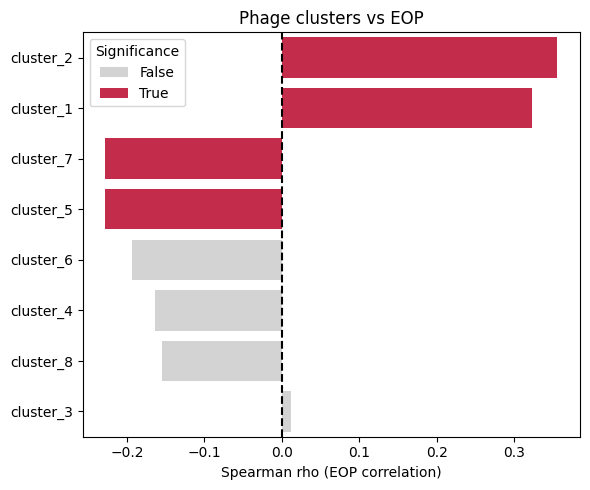

In [73]:
# Combine simplified tables
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_correlations(df, feature_col, rho_col, p_col, title):
    df = df.copy()
    df["Significance"] = df[p_col] < 0.05
    plt.figure(figsize=(6, len(df)*0.5 + 1))
    sns.barplot(data=df, x=rho_col, y=feature_col, hue="Significance",
                palette={True: "crimson", False: "lightgrey"}, dodge=False)
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


plot_correlations(cluster_corr_df, "cluster", "spearman_rho", "p_adj",
                  "Phage clusters vs EOP")

In [ ]:
combined_with_clusters.to_csv("combined_with_clusters.tsv", sep="\t", index=False)


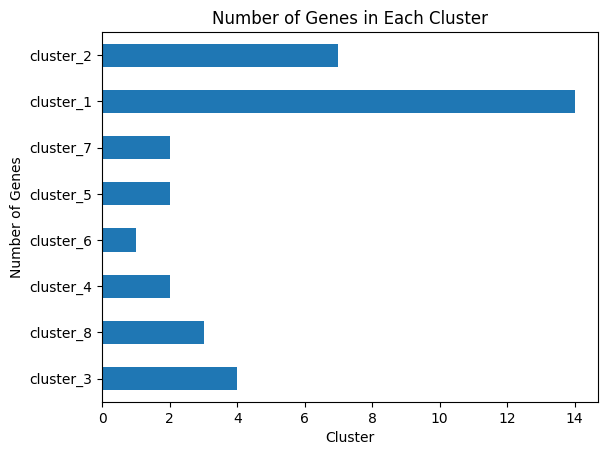

In [75]:
#plot bar graph with number of genes in each cluster
order = ["cluster_3", "cluster_8", "cluster_4", "cluster_6", "cluster_5","cluster_7","cluster_1", "cluster_2"]

counts = (
    combined_with_clusters
    .groupby("cluster")["gene"]   # or "Protein id", etc.
    .nunique()
)

counts = counts.reindex(order)  # reorders to your order

counts.plot(kind='barh')
plt.xlabel('Cluster')
plt.ylabel('Number of Genes')
plt.title('Number of Genes in Each Cluster')
plt.show()

/tmp/ipython-input-3612367331.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(unique_genes)


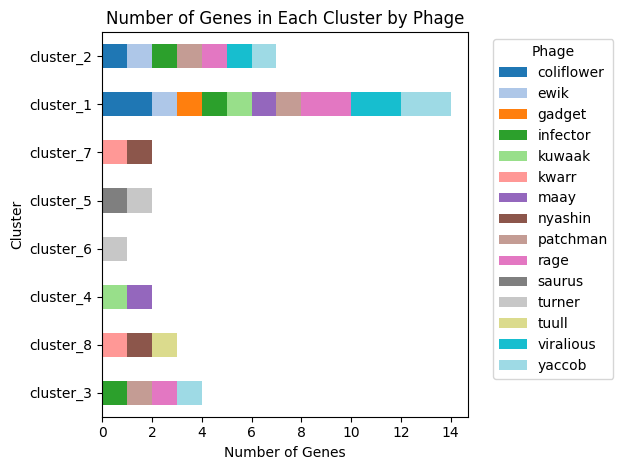

In [76]:
# function to count unique genes per group
def unique_genes(df):
    return df['gene'].nunique()  # or df['Protein id'].nunique()

stack_counts = (
    combined_with_clusters
    .groupby(["cluster", "phage"])
    .apply(unique_genes)
    .reset_index(name="gene_count")
)

stack_wide = (
    stack_counts
    .pivot(index="cluster", columns="phage", values="gene_count")
    .fillna(0)
)

stack_wide = stack_wide.reindex(order)  # reorder clusters like in your first plot

stack_wide.plot(
    kind="barh",
    stacked=True,
    colormap=plt.get_cmap("tab20")
)

plt.xlabel("Number of Genes")
plt.ylabel("Cluster")
plt.title("Number of Genes in Each Cluster by Phage")
plt.legend(title="Phage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
